In [2]:
import numpy as np
import scipy.sparse as sp
import sknetwork as sn
import abcd_graph
import matplotlib.pyplot as plt
from tqdm import tqdm

from clusim.clustering import Clustering
import clusim.sim as sim
import clusim.clugen as clugen
import clusim.clusimelement as elsim

from egosplit_sknetwork import EgoSplit

import os
import subprocess
import csv
import time

from fstar import *

import matplotlib.gridspec as gridspec
from matplotlib import rc
import matplotlib.pylab as plt

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [3]:
measure_list = ['omega_index', 'onmi', 'oNMI', 'elmsim', "fstar"]
measure_name = ['Omega', r'$\mathrm{oNMI_{LFK}}$', r'$\mathrm{oNMI_{MGH}}$', 'ECC', r"$\mathrm{F^*_{wo}}$"]
n_measures = len(measure_list)

def hex2rgb(value):
    value = value.lstrip('#')
    lv = len(value)
    return tuple(int(value[i:i + lv // 3], 16)/255. for i in range(0, lv, lv // 3))


def set_size(w,h, ax=None):
    """ w, h: width, height in cm """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)/2.54 #2.54 cm per inch
    figh = float(h)/(t-b)/2.54 
    ax.figure.set_size_inches(figw, figh)

BiasColorDict = {}
BiasColorDict['omega_index'] = hex2rgb("#59a89c")
BiasColorDict['onmi'] = hex2rgb("#f0c571")
BiasColorDict['oNMI'] = hex2rgb('#C86629')
BiasColorDict['elmsim'] = hex2rgb("#082a54")
BiasColorDict['fstar'] = hex2rgb("#e02b35")

In [4]:
## Helper functions for massaging input type

def sparse_to_clustering(sparse):
    cluster_list = list(sparse.tolil().rows)
    # outlier_ids = np.arange(sparse.shape[1])[sparse.getnnz(0) == 0]
    # for outlier_id in outlier_ids:
    #     cluster_list.append([outlier_id])
    return Clustering().from_cluster_list(cluster_list) 


def clustering_to_sparse(clustering):
    clu2elm = clustering.to_clu2elm_dict()
    n_elem = len(clustering.to_elm2clu_dict())
    sparse = sp.lil_matrix((len(clu2elm), n_elem), dtype="bool")
    for clu, elms in clu2elm.items():
        elms = list(elms)
        sparse[clu, elms] = True
    return sparse.tocsr()

In [5]:
## overlapping NMI executable
oNMI_path = '../../Overlapping-NMI/onmi'

def oNMI(c1, c2):
    if isinstance(c1, np.ndarray):
        c1 = clustering_array_to_sparse(c1)
    elif isinstance(c1, Clustering):
        c1 = clustering_to_sparse(c1)
    if isinstance(c2, np.ndarray):
        c2 = clustering_array_to_sparse(c2)
    elif isinstance(c2, Clustering):
        c2 = clustering_to_sparse(c2)

    # Convert clusterings to a list of lists
    c1 = list(c1.tolil().rows)
    with open("c1.csv", "w") as f:
        wr = csv.writer(f, delimiter=" ")
        wr.writerows(c1)
    f.close()
    c2 = list(c2.tolil().rows)
    with open("c2.csv", "w") as f:
        wr = csv.writer(f, delimiter=" ")
        wr.writerows(c2)
    f.close()
    start = time.time()
    x = float(subprocess.check_output([oNMI_path,"c1.csv","c2.csv"]).decode("utf-8").split()[1])
    t = time.time() - start
    _ = os.system('rm c1.csv')
    _ = os.system('rm c2.csv')
    return x, t

In [6]:
def elmsim(c1, c2):
    # set paramter values for element_centric similarity
    return np.mean(sim.element_sim_elscore(c1, c2, alpha = 0.9, differing_elements="isolated")[0])

In [7]:
# Function to handle building ABCD+oo graphs with the julia library
# Requires julia to be installed and ABCDGraphGenerator.jl to be added.

abcd_path = "~/Research/ABCDGraphGenerator.jl/utils/"
folder = "~/Research/Fstar/experiments/"
julia = "julia "


def run_abcd(
    n,
    xi,
    eta=1.,
    nout=0,
    gamma=2.5,
    delta=3,
    Delta=None,
    s=25,
    S=None,
    beta=1.5,
    d=8,
    rho=0.0,
    seed=42,
):
    if Delta is None:
        Delta =  int(np.sqrt(n))
    if S is None:
        S = int(n**0.75)
    if eta == 1:
        params = abcd_graph.ABCDParams(
            vcount=n,
            xi=xi,
            num_outliers=nout,
            min_degree=delta,
            max_degree=Delta,
            gamma=gamma,
            min_community_size=s,
            max_community_size=S,
            beta=beta,
        )
        graph = abcd_graph.ABCDGraph(params).build()
        labels = np.empty(n, dtype="int32")
        for i, com in enumerate(graph.communities):
            labels[com.vertices] = i
        if nout > 0:
            labels[labels == np.max(labels)] = -1
        adjacency = graph.exporter.to_sparse_adjacency_matrix()
        return adjacency, labels

    # ABCDoo needs julia version
    if julia is None or folder is None or abcd_path is None:
        raise ValueError("Must pass julia, folder, and abcd_path if eta>1")
    config = f'''seed = "{seed}"                   # RNG seed, use "" for no seeding
n = "{n}"                   # number of vertices in graph
nout = "{nout}"                  # number of vertices in graph that are outliers
t1 = "{gamma}"                      # power-law exponent for degree distribution
d_min = "{delta}"                   # minimum degree
d_max = "{Delta}"                  # maximum degree
d_max_iter = "1000"           # maximum number of iterations for sampling degrees
t2 = "{beta}"                      # power-law exponent for cluster size distribution
c_min = "{s}"                  # minimum cluster size after growing
c_max = "{S}"                # maximum cluster size after growing
c_max_iter = "1000"           # maximum number of iterations for sampling cluster sizes
xi = "{xi}"                    # fraction of edges to fall in background graph
eta = "{eta}"                   # average number of community per community node
d = "{d}"                       # dimensionality of latent space
rho = "{rho}"                   # correlation between degree and number of communities node is in
degreefile = "deg_{seed}.dat"        # name of file do generate that contains vertex degrees
communitysizesfile = "cs_{seed}.dat" # name of file do generate that contains community sizes
communityfile = "com_{seed}.dat"     # name of file do generate that contains assignments of vertices to communities
networkfile = "edge_{seed}.dat" '''
    config_file = f'config_{seed}.dat'
    with open(config_file, 'w') as f:
        print(config, file=f)

    cmd = julia+" "+abcd_path+'abcd_oo_sampler.jl ' + folder+"/"+config_file
    os.system(cmd+' >/dev/null 2>&1')

    adjacency = sn.data.from_csv(f'edge_{seed}.dat')
    adjacency = adjacency[1:][:, 1:]

    list_of_coms = []
    n_coms = 0
    with open(f'com_{seed}.dat', "r") as file:
        for line in file:
            # each line has the format: node_id\t[a,b,c]\n
            # for this node belonging to communities a,b,c
            # if there are outliers then they have community [-1]
            # node_id counts up starting at 0
            x = line.split('\t')[1].rstrip()[1:-1] # gets a,b,c
            x_coms = [int(y) for y in x.split(',')]
            list_of_coms.append(np.array(x_coms))
            n_coms = max(n_coms, max(x_coms))

    labels = sp.lil_matrix((adjacency.shape[0], n_coms-1), dtype="bool")
    for x, x_coms in enumerate(list_of_coms):
        if x_coms[0] == 1:
            continue
        labels[x, x_coms - 2] = True
    labels = labels.transpose().tocsr()
    
    cmd = f'rm *_{seed}.dat'
    os.system(cmd+' >/dev/null 2>&1')

    return adjacency, labels

In [39]:
ns = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
eta = 2
xi = 0.3
runs = 10

times = np.empty((n_measures, len(ns), runs), dtype="float64")
for j, n in enumerate(ns):
    print(n)
    for r in range(runs):
        print("\t", r+1)
        adj, lab = run_abcd(n, xi, eta=eta)
        pred = EgoSplit(min_cluster_size=1).fit_predict(adj)
        
        lab_c = sparse_to_clustering(lab)
        pred_c = sparse_to_clustering(pred)

        for i in range(n_measures):
            print("\t\t", measure_list[i])
            if measure_list[i] in ["fstar"]:
                start = time.time()
                eval(measure_list[i]+'(lab, pred)')
                times[i, j, r] = time.time() - start
            elif measure_list[i] in ["oNMI"]:
                x, t = eval(measure_list[i]+'(lab, pred)')
                times[i, j, r] = t
            elif measure_list[i] in ['elmsim']:
                start = time.time()
                eval(measure_list[i]+'(lab_c, pred_c)')
                times[i, j, r] = time.time() - start
            else:
                start = time.time()
                eval('sim.'+measure_list[i]+'(lab_c, pred_c)')
                times[i, j, r] = time.time() - start
np.save("times_n.npy", times)

100
	 1
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 2
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 3
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 4
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 5
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 6
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 7
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 8
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 9
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 10
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
200
	 1
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 2
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 3
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 4
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 5
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 6
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 7
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 8
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 9
		 omega_index


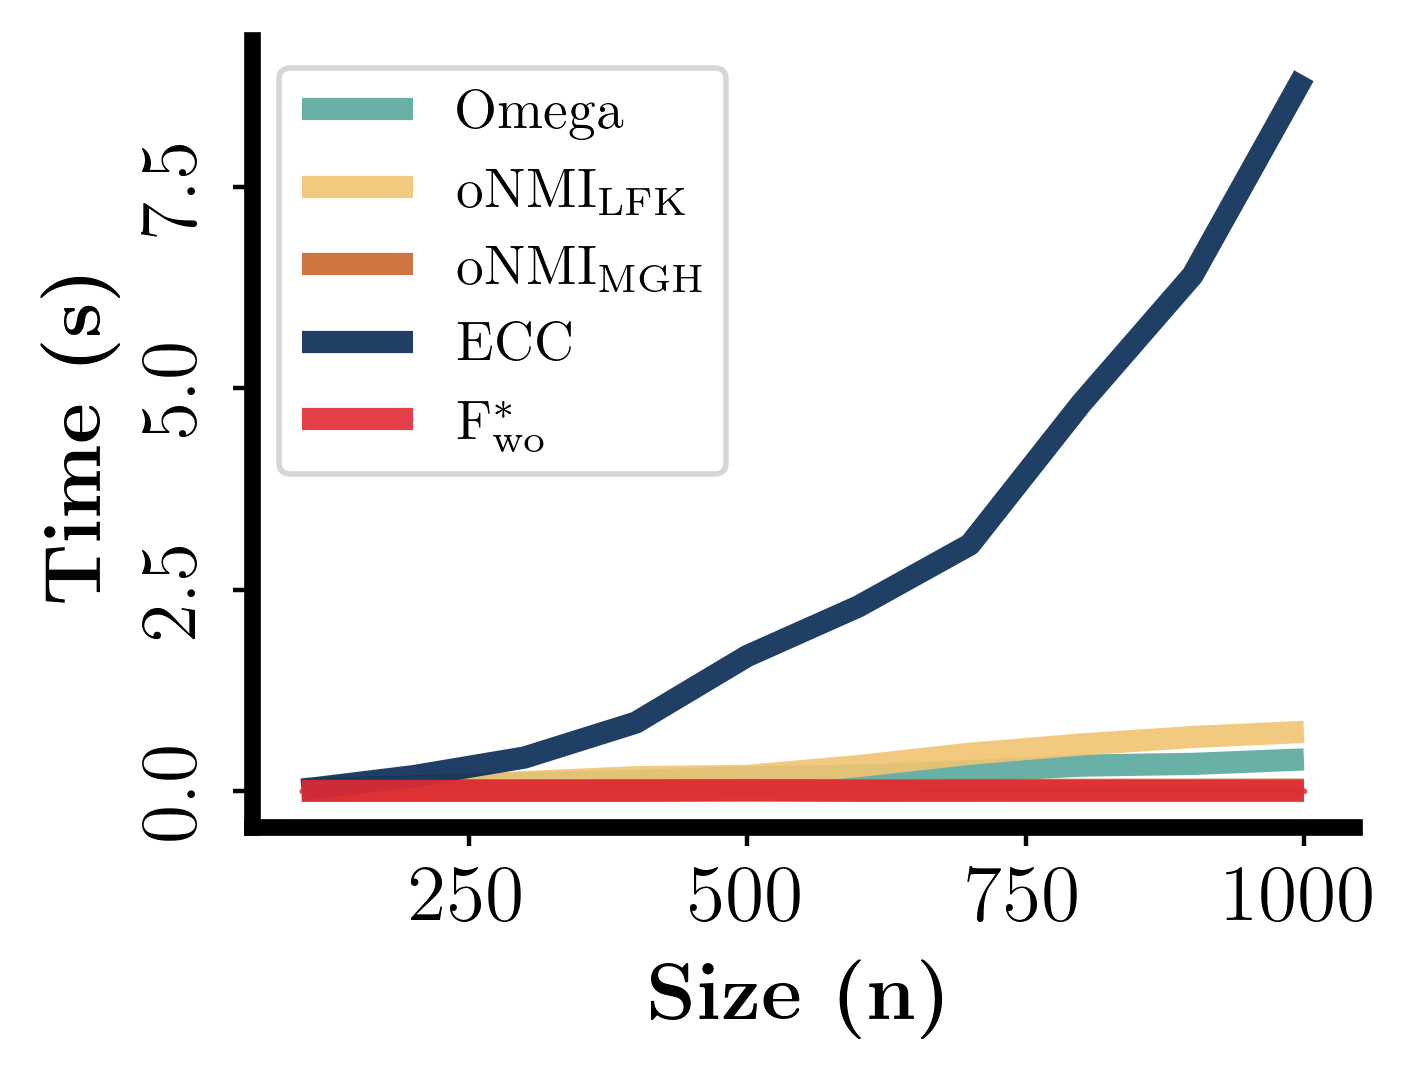

In [40]:
# plot results
times = np.load("times_n.npy")
means = np.mean(times, axis=2)
stds = np.std(times, axis=2)

fig, ax = plt.subplots(dpi=400)

for i in range(n_measures):
    line = ax.plot(ns, means[i], color = BiasColorDict[measure_list[i]],
                label = measure_list[i], alpha = 0.9, lw = 4, dashes = [500,1])
    
for imeasure in range(n_measures):
    ax.fill_between(ns, means[i] - stds[i], 
                    means[i] + stds[i], 
                    color = BiasColorDict[measure_list[i]], alpha = 0.3)

# ax.set_xlim([0,1.05])
# ax.set_ylim([0, 1])
# ax.set_xticks([0.0, 0.5, 1.0])
# ax.set_yticks([0.0, 0.5, 1.0])
plt.yticks(rotation=90, va="center")
ax.tick_params(labelsize=14.4)

ax.set_xlabel(r'\Large\bf Size (n)')
ax.set_ylabel(r'\Large \bf Time (s)')

for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)

ax.legend(labels=measure_name)
set_size(7,5)
plt.show()

In [7]:
ns = [2**8, 2**9, 2**10, 2**11, 2**12]
eta = 2
xi = 0.3
runs = 10

times = np.empty((n_measures, len(ns), runs), dtype="float64")
for j, n in enumerate(ns):
    print(n)
    for r in range(runs):
        print("\t", r+1)
        adj, lab = run_abcd(n, xi, eta=eta)
        pred = EgoSplit(min_cluster_size=1).fit_predict(adj)
        
        lab_c = sparse_to_clustering(lab)
        pred_c = sparse_to_clustering(pred)

        for i in range(n_measures):
            
            print("\t\t", measure_list[i])
            if measure_list[i] in ["fstar"]:
                start = time.time()
                eval(measure_list[i]+'(lab, pred)')
                times[i, j, r] = time.time() - start
            elif measure_list[i] in ["oNMI"]:
                x, t = eval(measure_list[i]+'(lab, pred)')
                times[i, j, r] = t
            elif measure_list[i] in ['elmsim']:
                start = time.time()
                eval(measure_list[i]+'(lab_c, pred_c)')
                times[i, j, r] = time.time() - start
            else:
                start = time.time()
                eval('sim.'+measure_list[i]+'(lab_c, pred_c)')
                times[i, j, r] = time.time() - start
np.save("times_n2.npy", times)

256
	 1
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 2
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 3
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 4
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 5
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 6
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 7
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 8
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 9
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 10
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
512
	 1
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 2
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 3
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 4
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 5
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 6
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 7
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 8
		 omega_index
		 onmi
		 oNMI
		 elmsim
		 fstar
	 9
		 omega_index


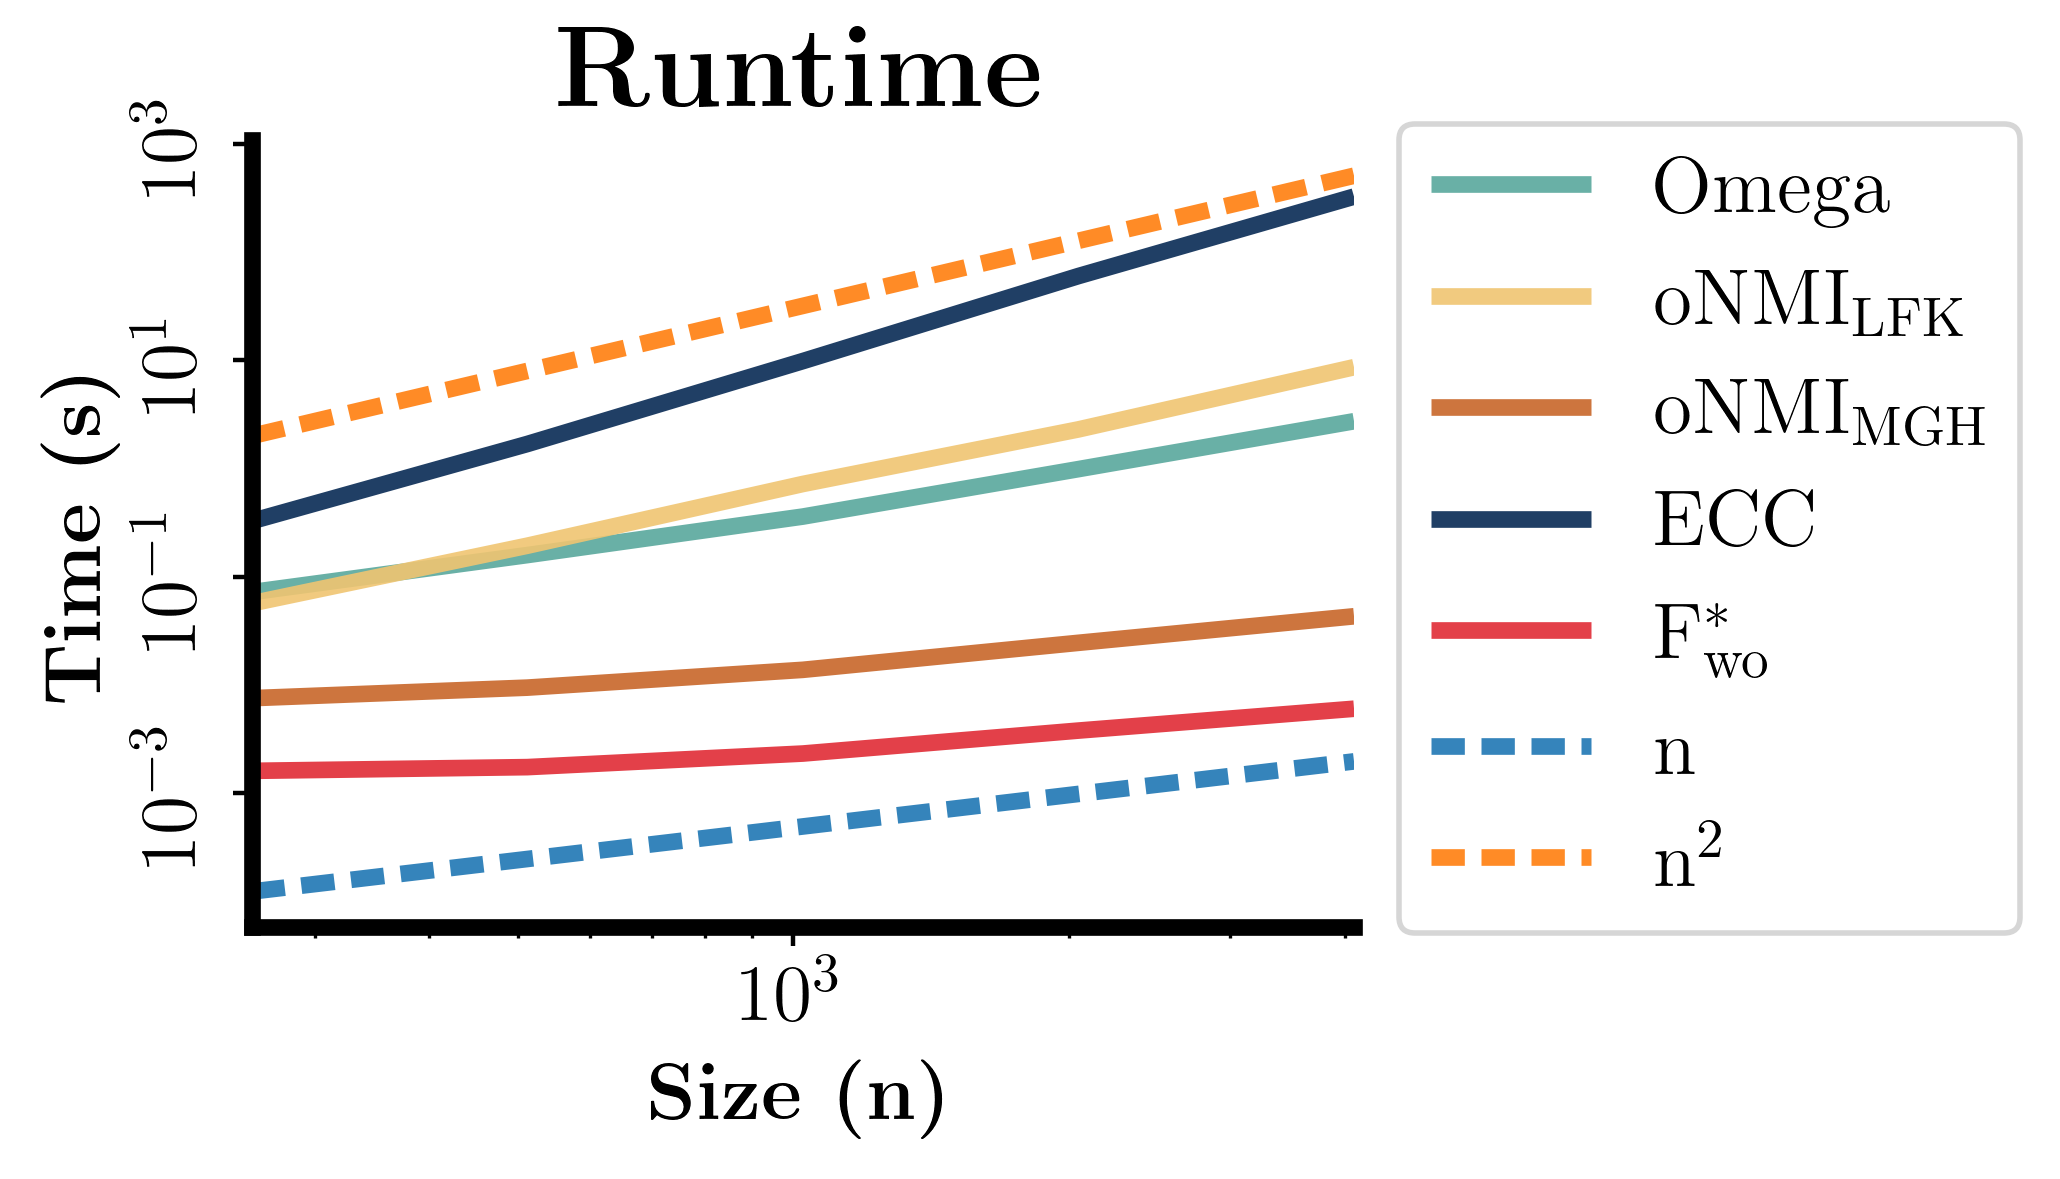

In [63]:
# plot results
ns = [2**8, 2**9, 2**10, 2**11, 2**12]
times = np.load("times_n2.npy")
means = np.mean(times, axis=2)
stds = np.std(times, axis=2)

fig, ax = plt.subplots(dpi=400)

for i in range(n_measures):
    line = ax.plot(ns, means[i], color = BiasColorDict[measure_list[i]],
                label = measure_list[i], alpha = 0.9, lw = 3, dashes = [500,1])

ny = [2**-13, 2**-12, 2**-11, 2**-10, 2**-9]
ax.plot(ns, ny, label="n", alpha = 0.9, lw = 3, dashes = [2,1])
n2y = 2 ** (2*np.arange(5)+1)
ax.plot(ns, n2y, label=r"n$^2$", alpha = 0.9, lw = 3, dashes = [2,1])

ax.set_xlim([2**8, 2**12])
# ax.set_ylim([0, 1])
# ax.set_xticks([10**2.5, 10**3, 10**3.5])
# ax.set_yticks([0.0, 0.5, 1.0])
plt.yticks(rotation=90, va="center")
ax.tick_params(labelsize=14.4)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r'\Large\bf Size (n)')
ax.set_ylabel(r'\Large \bf Time (s)')

for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(3)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    measure_name+["n", r"n$^2$"],
    bbox_to_anchor=[1.15, 0.5], 
    loc='center', 
    ncol=1,
    fancybox=True,
    fontsize=14.4
)
ax.set_title(r"\huge \bf Runtime")
set_size(7,5)
fig.savefig("fig4.pdf", bbox_inches="tight")
plt.show()